In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set academic plotting style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.dpi'] = 300

# Set random seed for reproducibility
np.random.seed(42)


In [3]:
# Load and prepare the data
file_path = 'dv0_witoutstraw.xlsx'
data = pd.read_excel(file_path)

# Filter for drinking events only
data = data[data['Label'] == 1]

# Group by participant and sip to get time steps and dV
grouped_data = data.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),
    dV=('dV', 'first'),
    Label=('Label', 'first')
).reset_index()

print("Dataset Overview:")
print(f"Total sips: {len(grouped_data)}")
print(f"Participants: {grouped_data['Participant_ID'].nunique()}")
print(f"Average sip volume: {grouped_data['dV'].mean():.2f} ml")
print(f"Volume range: {grouped_data['dV'].min():.2f} - {grouped_data['dV'].max():.2f} ml")

# Prepare features and target
X = grouped_data[['time_steps']]
y = grouped_data['dV']

# Split the data (80% train, 20% test) - same as original analysis
train_size = int(0.8 * len(grouped_data))
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]


Dataset Overview:
Total sips: 316
Participants: 39
Average sip volume: 29.02 ml
Volume range: 0.00 - 160.20 ml


In [4]:
# Define models with random seed 42 (same as original analysis)
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store results
results = {}

print("=" * 80)
print("REGRESSION MODEL EVALUATION RESULTS (Seed: 42)")
print("=" * 80)

for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100
    
    # Store results
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }
    
    print(f"\n{model_name}:")
    print(f"  R² = {r2:.4f}")
    print(f"  RMSE = {rmse:.2f} ml")
    print(f"  MAE = {mae:.2f} ml")
    print(f"  RMSPE = {rmspe:.1f}%")


REGRESSION MODEL EVALUATION RESULTS (Seed: 42)

Linear Regression:
  R² = -0.2763
  RMSE = 19.92 ml
  MAE = 13.09 ml
  RMSPE = 68.6%

Support Vector Regression:
  R² = -0.2805
  RMSE = 19.95 ml
  MAE = 12.02 ml
  RMSPE = 47.3%

Decision Tree:
  R² = -0.8332
  RMSE = 23.87 ml
  MAE = 15.98 ml
  RMSPE = 94.3%

Random Forest:
  R² = -0.6980
  RMSE = 22.97 ml
  MAE = 15.56 ml
  RMSPE = 89.1%

Gradient Boosting:
  R² = -0.7671
  RMSE = 23.43 ml
  MAE = 15.85 ml
  RMSPE = 91.4%

K-Nearest Neighbors:
  R² = -0.9566
  RMSE = 24.66 ml
  MAE = 17.85 ml
  RMSPE = 95.2%


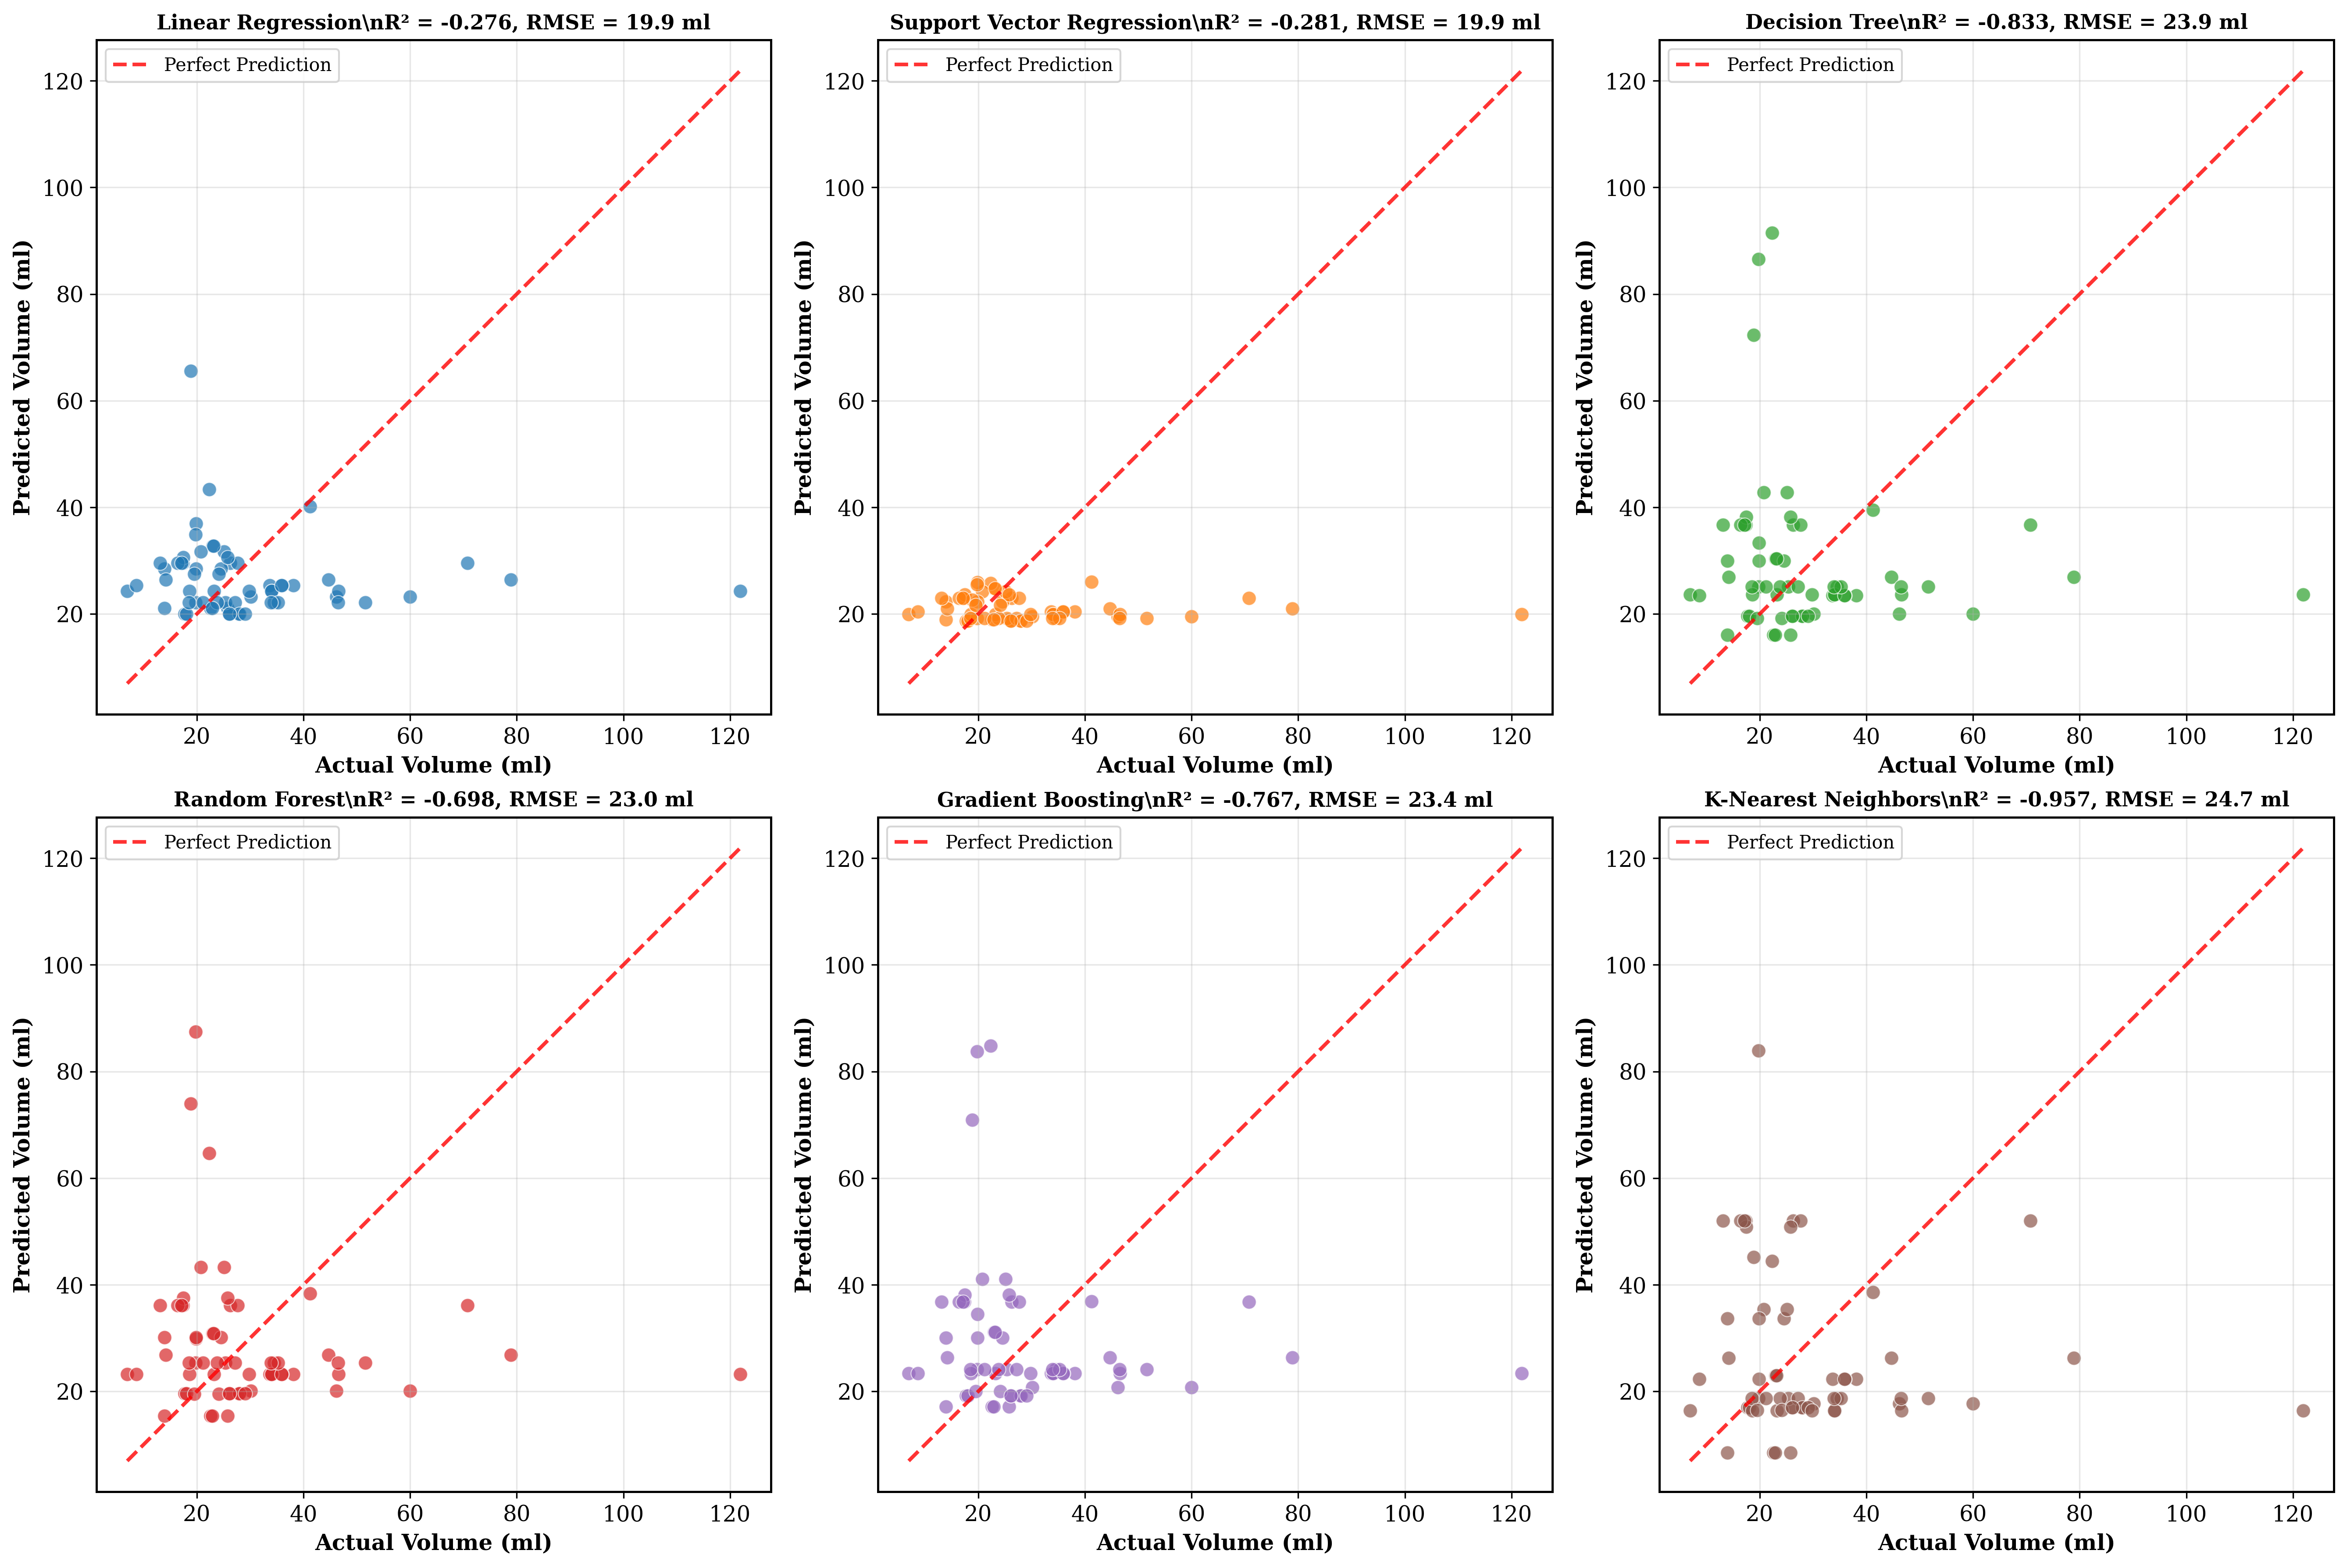

In [5]:
# Create academic-friendly regression plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (model_name, model_results) in enumerate(results.items()):
    ax = axes[idx]
    y_pred = model_results['Predictions']
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.7, color=colors[idx], s=60, edgecolors='white', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.8, label='Perfect Prediction')
    
    # Formatting
    ax.set_xlabel('Actual Volume (ml)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Volume (ml)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name}\\nR² = {model_results["R²"]:.3f}, RMSE = {model_results["RMSE"]:.1f} ml', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    # Set equal aspect ratio
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('academic_regression_plots.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Create comprehensive metrics comparison plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# R² Score comparison
ax1 = axes[0, 0]
r2_scores = [results[model]['R²'] for model in results.keys()]
model_names = list(results.keys())
bars1 = ax1.bar(model_names, r2_scores, color=colors[:len(model_names)], alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_title('R² Score Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)

# Add value labels on bars
for bar, score in zip(bars1, r2_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# RMSE comparison
ax2 = axes[0, 1]
rmse_scores = [results[model]['RMSE'] for model in results.keys()]
bars2 = ax2.bar(model_names, rmse_scores, color=colors[:len(model_names)], alpha=0.8, edgecolor='black', linewidth=1)
ax2.set_title('RMSE Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('RMSE (ml)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars2, rmse_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{score:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# MAE comparison
ax3 = axes[1, 0]
mae_scores = [results[model]['MAE'] for model in results.keys()]
bars3 = ax3.bar(model_names, mae_scores, color=colors[:len(model_names)], alpha=0.8, edgecolor='black', linewidth=1)
ax3.set_title('MAE Comparison', fontsize=14, fontweight='bold')
ax3.set_ylabel('MAE (ml)', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars3, mae_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{score:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# RMSPE comparison
ax4 = axes[1, 1]
rmspe_scores = [results[model]['RMSPE'] for model in results.keys()]
bars4 = ax4.bar(model_names, rmspe_scores, color=colors[:len(model_names)], alpha=0.8, edgecolor='black', linewidth=1)
ax4.set_title('RMSPE Comparison', fontsize=14, fontweight='bold')
ax4.set_ylabel('RMSPE (%)', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars4, rmspe_scores):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{score:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('academic_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
